In [ ]:
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.axes import Axes
import spikeinterface as si 
import cv2
from data_analysis.plotting import get_c_map_colors
from data_analysis.mea_analysis import SAMPLING_RATE
import data_analysis.mea_analysis as mea

In [2]:
BRW_BASE_FOLDER = Path("/media/ferdinand-forberger/RawDataBackUp")
MAIN_FOLDER = Path("/media/ferdinand-forberger/Seagate Portable Drive")
df_overview = mea.get_overview(MAIN_FOLDER)
df_overview = df_overview[df_overview["sles_saved"]==True]
df_overview.reset_index(inplace=True, drop=True)
df_overview["image_path"]= df_overview["folder_path"].astype(str) + "/org_image.png"
df_overview["mask_path"] = df_overview["folder_path"].astype(str) + "/mask.png"
df_overview["slcc_path"] = df_overview["folder_path"] / "sttc.npy"
mea_img = plt.imread("/media/ferdinand-forberger/RawDataBackUp/8561_5/MEA.jpg")

In [3]:
def propagation_plot(indices_to_plot: list, 
                     axes: Axes, 
                     org_img: np.ndarray, 
                     filtered_first_spikes : list,
                     filtered_chans : list):
    for i, j in enumerate(indices_to_plot):
        
        st = filtered_first_spikes[j]
        chans = filtered_chans[j].copy()
        heatmap = np.full(4096, np.nan)
        heatmap[chans] = st
        heatmap = heatmap.reshape(64,64)
        org_img_shape = org_img.shape[:2]
        heatmap = cv2.resize(heatmap,org_img_shape, interpolation=cv2.INTER_NEAREST)
        axes[i].imshow(org_img)
        axes[i].imshow(heatmap)
        axes[i].set_axis_off()

        cbar = plt.colorbar(axes[i].images[1], ax=axes[i], shrink=0.5, pad=0.01)
        cbar.set_label("First spike time [s]", rotation=270, labelpad=15)


0it [00:00, ?it/s]

8561_5


/home/ferdinand-forberger/.conda/envs/rapids-25.04/lib/python3.12/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1746251341172/work/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


Comparison of Labels (Original vs. Changed)
KSLabel agreement: 554, disagreement: 0
Number of good clusters (Original): 119
Number of good clusters (Changed): 119
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 554, disagreement: 0
Number of good clusters (Original): 119
Number of good clusters (Changed): 119
-------------------------------------------------------


100%|██████████| 554/554 [00:00<00:00, 1477.94it/s]


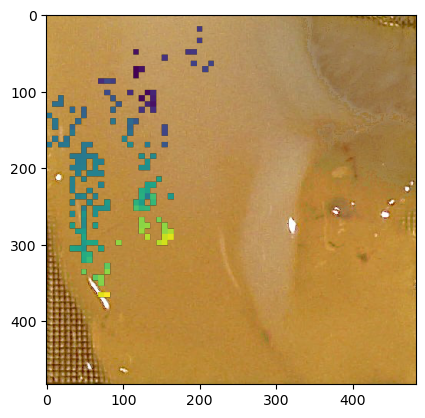

22it [00:06,  3.64it/s]


In [4]:
origins = []
org_imgs = []
filtered_first_spikes_list = []
filtered_chans_list = []

for i, row in tqdm(df_overview.iterrows()):
    if  row["folder"] not in ["8561_5"]:
        continue
    print(row["folder"])
    st_df, st, clu, best_cha_st, vectorized_map =  mea.get_stdf(row["folder_path"])
    burst_json_path = Path(row["folder_path"]) / "burst_params.json"
    sles = np.load(row["sle_path"])
    image_path = Path(row["folder_path"]) / Path("org_image.png")
    org_img = cv2.imread(image_path)
    org_img = cv2.cvtColor(org_img, cv2.COLOR_BGR2RGB)
    
    #estimate sle origin and and filter spike sorted data
    res = mea.filter_spikes_find_origin(sles=sles,
                                                st=st,
                                                clu=clu,
                                                cluster_to_channel_map=vectorized_map, 
                                                burst_json_path=burst_json_path, 
                                                folder_path=row["folder_path"])
    estimated_SLE_orgins, first_spikes, unique_chans_list, filtered_first_spikes, filtered_chans, chan_subsets = res
    origins.append(estimated_SLE_orgins)
    org_imgs.append(org_img)
    filtered_first_spikes_list.append(filtered_first_spikes)
    filtered_chans_list.append(filtered_chans)

    plt.figure()
    heatmap = np.full(4096, np.nan)
    heatmap[filtered_chans[1]] = filtered_first_spikes[1]
    heatmap = heatmap.reshape(64,64)
    heatmap = cv2.resize(heatmap, (org_img.shape[1], org_img.shape[0]), interpolation=cv2.INTER_NEAREST)
    plt.imshow(org_img)
    plt.imshow(heatmap)
    plt.show()

row = df_overview[df_overview["folder"]=="8561_5"].iloc[0]

In [5]:
x_coords, y_coords = mea.chans_to_coords(best_cha_st)
x_all_img, y_all_img = mea.to_img_coord(img=org_img, x=x_coords, y=y_coords)

In [6]:
table_to_plot = pd.DataFrame({"Cluster": clu,
                              "Spike time": st,
                              "X coords": x_coords,
                              "Y coords": y_coords})
table_to_plot["Cluster"] = table_to_plot["Cluster"].astype(str)
table_to_plot["Spike time"] = (table_to_plot["Spike time"] / SAMPLING_RATE).round(3).astype(str)
table_to_plot["X coords"] = table_to_plot["X coords"].astype(str)
table_to_plot["Y coords"] = table_to_plot["Y coords"].astype(str)


In [7]:
table_to_plot = table_to_plot.loc[:10]

In [8]:
table_colors = get_c_map_colors(10)

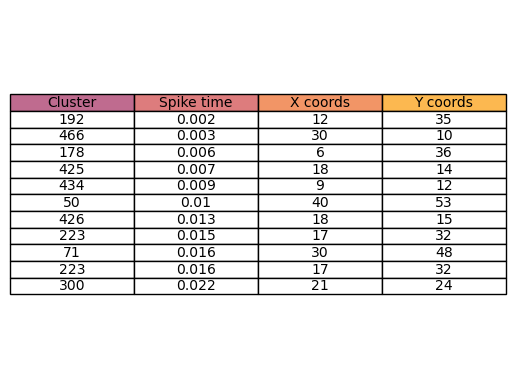

In [9]:
alpha = 0.7
table_colors_with_alpha = []
for color in table_colors:
    if isinstance(color, str) and color.startswith('#'):
        if len(color) == 7: 
            alpha_hex = format(int(alpha * 255), '02x') 
            table_colors_with_alpha.append(color + alpha_hex)
        elif len(color) == 9: 
            alpha_hex = format(int(alpha * 255), '02x')
            table_colors_with_alpha.append(color[:7] + alpha_hex)
        else:
            table_colors_with_alpha.append(color) 
    elif isinstance(color, (tuple, list)) and len(color) == 3: 
        table_colors_with_alpha.append((color[0], color[1], color[2], alpha))
    elif isinstance(color, (tuple, list)) and len(color) == 4:
        table_colors_with_alpha.append((color[0], color[1], color[2], alpha))
    else:
        table_colors_with_alpha.append(color)


# Create the plot and table
fig, ax = plt.subplots()
ax.axis('tight')
ax.axis('off')

table = plt.table(cellText=table_to_plot.values,
                  colLabels=table_to_plot.columns,
                  cellLoc='center',
                  loc='center',
                  colColours=table_colors_with_alpha[4:9]) # Use the colors with alpha

plt.show()

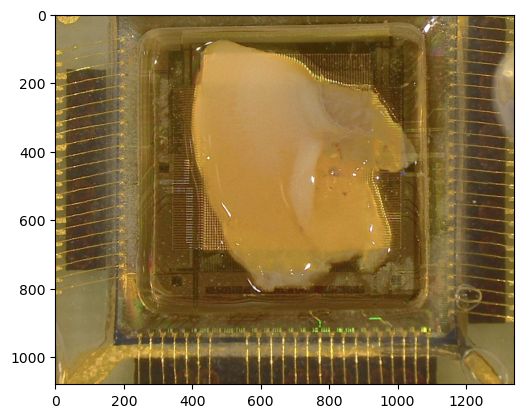

In [10]:
MEA_img = cv2.imread("/media/ferdinand-forberger/RawDataBackUp/8561_5/MEA.jpg")
MEA_img = cv2.cvtColor(MEA_img, cv2.COLOR_BGR2RGB)
mea_pic = MEA_img.copy()
plt.imshow(MEA_img)

In [11]:
def calculate_COAT(st_event,chans_event):
    d_idx = 700
    overlap_idx = 500
    start_frame = st_event[0]
    end_frame = st_event[-1]

    start_frames = np.arange(start_frame, end_frame, (d_idx-overlap_idx))
    COAT = []
    for start_frame in start_frames:
        end_frame = start_frame + d_idx
        time_mask = (st_event >= start_frame) & (st_event < end_frame)
        st_loc = st_event[time_mask]
        chan_loc = chans_event[time_mask]


        a = [np.sum(chan_loc == chan)/(end_frame-start_frame) for chan in np.unique(chan_loc)]
        a = np.array(a)
        x_loc, y_loc = mea.chans_to_coords(np.unique(chan_loc))
        coa = mea.calculate_center_of_activity_2d(a=a, x=x_loc, y=y_loc)


        COAT.append(coa)
    COAT = np.array(COAT)

    return COAT

def calculate_COAT_wrapper(st : np.ndarray, chans: np.ndarray, sle_start:int, sle_end:int):
    st_event = st[(st>=sle_start)&(st<=sle_end)]
    chans_event = chans[(st>=sle_start)&(st<=sle_end)]

    
    x_coords, y_coords = mea.chans_to_coords(chans_event)
    x_coords, y_coords = mea.to_img_coord(img=org_img, x=x_coords, y=y_coords)
    
    
    COAT = calculate_COAT(st_event, chans_event)

    COAT_x = COAT[:, 0]
    COAT_y = COAT[:, 1]
    COAT_x, COAT_y = mea.to_img_coord(img=org_img, x=COAT_x, y=COAT_y)

    return COAT

In [12]:
n_jobs = 11
sles = np.load(row["sle_path"])
sle_starts = sles[0,:]
sle_ends = sles[1,:]
st_df, st, clu, best_cha_st, vectorized_map =  mea.get_stdf(row["folder_path"])
#SOATs = Parallel(n_jobs=n_jobs)(delayed(calculate_COAT_wrapper)(st, best_cha_st, sle_start, sle_end) for sle_start, sle_end in zip(sle_starts, sle_ends))
SOATs = []
i = 0
x_coords, y_coords = mea.chans_to_coords(best_cha_st)
x_coords, y_coords = mea.to_img_coord(img=org_img, x=x_coords, y=y_coords)


for sle_start, sle_end in zip(sle_starts, sle_ends):
    


    COAT = calculate_COAT_wrapper(st = st, chans=best_cha_st, sle_start = sle_start, sle_end=sle_end)
    COAT[:,0] = COAT[:,0] / 64 * org_img.shape[1]
    COAT[:,1] = COAT[:,1] / 64 * org_img.shape[0]
    
    SOATs.append(COAT)
    i +=1


Comparison of Labels (Original vs. Changed)
KSLabel agreement: 554, disagreement: 0
Number of good clusters (Original): 119
Number of good clusters (Changed): 119
-------------------------------------------------------


75it [00:00, 13427.22it/s]


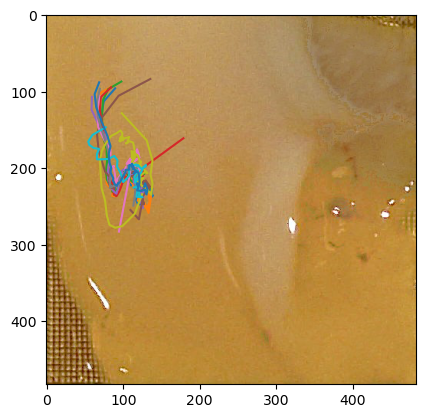

In [13]:
plt.imshow(org_img)
for i, SOAT in tqdm(enumerate(SOATs)):
    if i % 7 ==0:

        plt.plot(SOAT[:,0], SOAT[:,1])
    

In [14]:
sttc_matrix = np.load(row["slcc_path"])

In [15]:
import data_analysis.graphs as graphs

In [16]:
sttc_matrix[sttc_matrix <= 0] = 0 #we are not interested in anticorr connections!
assert ~np.any(sttc_matrix>1), "This is extreamly unlikely. Check the sttc matrix"
st_df, st, clu, best_cha_st, vectorized_map =  mea.get_stdf(row["folder_path"])

#identify single units
st_df = st_df[st_df["mua_labels"]=="good"]
st_df = st_df[st_df["num_spikes"]>300]
st_df.reset_index(inplace=True, drop=True)

#get coordinates of each spike sorted cluster
x, y= mea.chans_to_coords(st_df["chan_best"])
img_x_coords, img_y_coords = mea.to_img_coord(img=org_img, x=x, y=y)
st_df["x_coords"], st_df["y_coords"] = img_x_coords, img_y_coords
#chage st to s
st = st/SAMPLING_RATE

G = graphs.construct_graph(st_df, sttc_matrix)

Comparison of Labels (Original vs. Changed)
KSLabel agreement: 554, disagreement: 0
Number of good clusters (Original): 119
Number of good clusters (Changed): 119
-------------------------------------------------------
Optimized NetworkX graph constructed with 34 nodes and 498 edges.


In [17]:
node_pos = G.nodes(data=True)
poses = []
for item in node_pos:
    pos = item[1]["pos"]
    poses.append(pos)
poses = np.array(poses)

In [18]:
edges = G.edges(data=True)
edge_poses = []
edge_weights = []
for item in edges:
    pos1 = item[0]
    pos2 = item[1]
    print(pos1, pos2)
    edge_poses.append((node_pos[pos1]["pos"], node_pos[pos2]["pos"]))

    edge_weights.append(item[2]["weight"])
edge_poses = np.array(edge_poses)

426 371
426 425
426 139
426 382
426 333
426 405
426 521
426 499
426 51
426 300
426 449
426 471
426 448
426 427
426 215
426 431
426 507
426 189
426 437
426 63
426 122
426 477
426 230
426 149
426 357
426 216
426 308
426 450
426 54
426 29
426 162
371 425
371 139
371 382
371 113
371 333
371 405
371 298
371 521
371 499
371 51
371 300
371 449
371 471
371 448
371 427
371 215
371 431
371 507
371 189
371 437
371 63
371 122
371 477
371 230
371 149
371 357
371 216
371 308
371 450
371 54
371 29
371 162
425 382
425 113
425 333
425 405
425 521
425 499
425 51
425 300
425 449
425 471
425 448
425 427
425 215
425 431
425 507
425 189
425 437
425 63
425 122
425 477
425 230
425 357
425 216
425 308
425 450
425 54
425 29
425 162
139 113
139 333
139 298
139 431
139 149
382 113
382 333
382 405
382 521
382 499
382 51
382 300
382 449
382 471
382 448
382 427
382 215
382 431
382 507
382 189
382 437
382 63
382 122
382 477
382 230
382 149
382 357
382 216
382 308
382 450
382 54
382 29
382 162
333 113
333 405
333 298


In [19]:
degrees = G.degree()
degree_values = np.array([item[1] for item in degrees])

In [20]:
degree_values

array([31, 33, 30,  7, 31, 33, 29, 30, 31, 32, 31, 31, 31, 31, 31, 31, 31,
       31, 31, 31, 31, 31, 31, 31, 30, 31, 28, 31, 30, 31, 31, 31, 28,  4])

In [21]:
colors = get_c_map_colors()

In [22]:
node_alpha = (degree_values - np.min(degree_values)) / (np.max(degree_values) - np.min(degree_values))

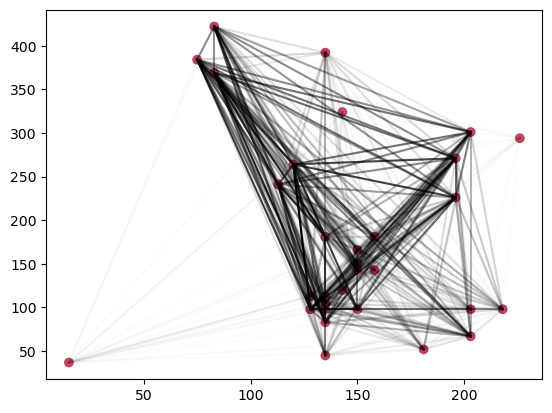

In [23]:
#plt.imshow(org_img)

plt.scatter(poses[:,0], poses[:,1], color=colors[2], alpha=node_alpha)
for i, edge in enumerate(edge_poses):
    alpha = edge_weights[i]**1.3 / np.max(edge_weights)**1.3
    plt.plot(edge[:,0], edge[:,1], color="black", alpha=alpha)

In [24]:
import cairosvg
from PIL import Image
from io import BytesIO

In [25]:
rat = plt.imread("/home/ferdinand-forberger/Downloads/Bild1.png")

In [26]:
rat = cv2.resize(rat, (1270, 1270), interpolation=cv2.INTER_AREA)

In [27]:
from matplotlib import patches

In [ ]:
def  plot_timeline(ax, 
                  timeline_start, 
                  timeline_end, 
                  ticks_x, 
                  ticklabels, 
                  text, 
                  brackets_starts,
                  brackets_ends,
                  bracket_text,
                  bracket_text_loc,
                  slash_breaks_tick,
                  unit_xticks,
                  units):
        
        assert len(ticks_x) == len(ticklabels)
        assert len(brackets_starts) == len(brackets_ends), "brackets_starts and brackets_ends must have the same length"
        assert len(brackets_starts) == len(bracket_text), "brackets_starts and bracket_text must have the same length"
        assert len(brackets_starts) == len(bracket_text_loc), "brackets_starts and bracket_text_loc must have the same length"
        
        ax.arrow(timeline_start, 0.0, timeline_end-timeline_start, 0,
                length_includes_head=True, 
                width=0.01,
                color="black",
                head_length = 5)

        # ticks
        for i, tick in enumerate(ticks_x):
                ax.vlines(tick, -0.06, 0.06, color="black", linewidth=1.5)
        
        # ticklabels
        for i, tick in enumerate(ticks_x):
                ax.text(tick, 0.1, ticklabels[i], 
                        horizontalalignment="center",
                        verticalalignment="bottom",
                        color="black")

        # text
        for i, t in enumerate(text):
                if i % 2 == 0:
                        # text below
                        ax.text(ticks_x[i],-0.1,t, 
                                horizontalalignment="center",
                                verticalalignment="top",
                                color="black")
                else:
                        # text above
                        ax.text(ticks_x[i],0.2,t, 
                                horizontalalignment="center",
                                verticalalignment="bottom",
                                color="black")
        # brackets
        for i, start in enumerate(brackets_starts):
                if bracket_text_loc[i] == "top":
                        ax.plot([start,start,brackets_ends[i],brackets_ends[i]],
                                [0.22,0.25,0.25,0.22],linewidth=2,
                                color="black")
                        ax.text((start+brackets_ends[i])/2,0.3,bracket_text[i], 
                                horizontalalignment="center",
                                verticalalignment="bottom",
                                color="black")
                else:
                        ax.plot([start,start,brackets_ends[i],brackets_ends[i]],
                                [-0.22,-0.25,-0.25,-0.22],linewidth=2,
                                color="black")
                        ax.text((start+brackets_ends[i])/2,-0.3,bracket_text[i], 
                                horizontalalignment="center",
                                verticalalignment="top",
                                color="black")
                        
        # units
        for i, unit in enumerate(units):
                ax.text(unit_xticks[i],0.1,unit, 
                        horizontalalignment="center",
                        verticalalignment="bottom",
                        color="black")
        # slashes
        for i, tick in enumerate(slash_breaks_tick):
                dx = 1
                tick_0 = tick - dx
                tick_1 = tick + dx

                dy=0.05
                ax.plot([tick_0,tick_1],[-dy,dy], color="black", linewidth=3)
                ax.plot([tick_0-2,tick_1-2],[-dy,dy], color="black", linewidth=3)
        ax.set_ylim(-0.4,0.4)   
        ax.set_axis_off()   

timeline_start = -20
timeline_end = 39
ticks_x = [-20, -10, 0, 10, 20, 30]
ticklabels = ["","","","0 min","80 min", "120 min"]
text = ["-80 days to -60 days:\nBirth",
        "-12 days to -10 days:\nGlioma implantation or\nsham operation",
        "0 days:\nBrain extraction",
        "Slice is introduced into\n disinhibition solution",]
brackets_starts = [20]
brackets_ends = [30]
bracket_text = ["Time frame during which\n10 minutes of activity\nare recorded"]
bracket_text_loc = ["bottom"]
slash_breaks_tick = []
unit_xticks = []
units = [] #   

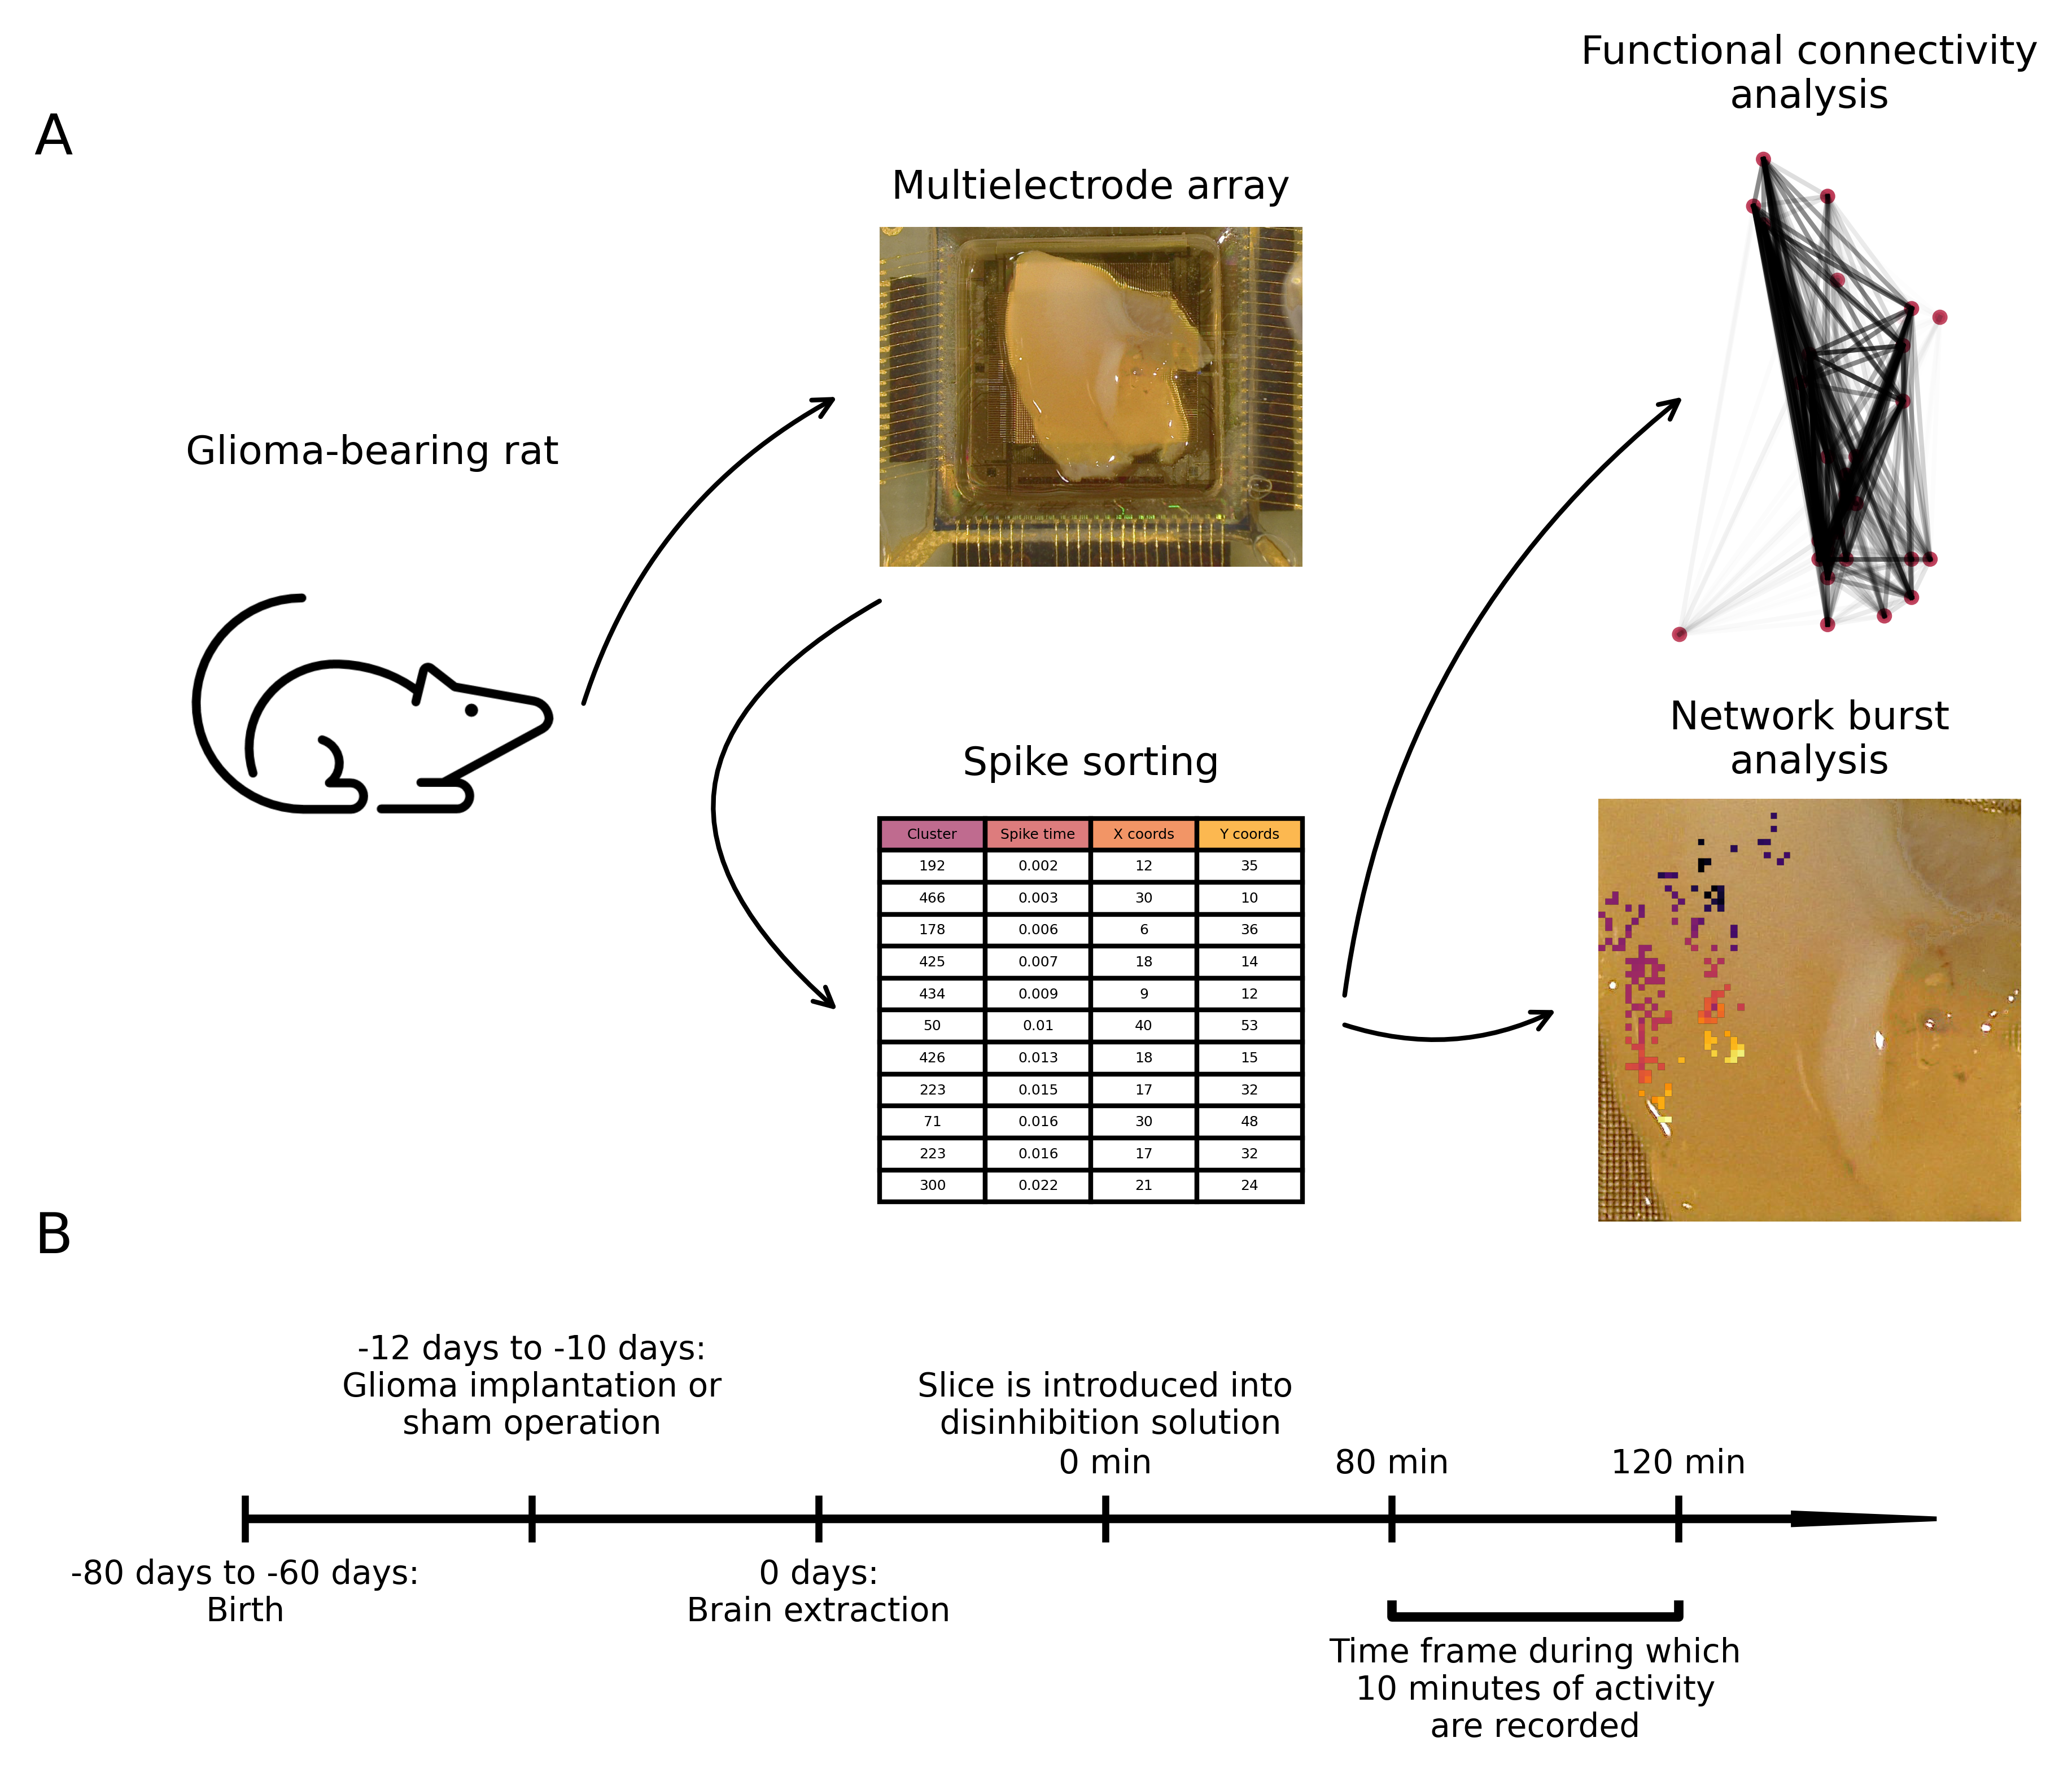

In [29]:
cm=1/2.54

plt.rcParams.update({'font.size': 7})
fig = plt.figure(figsize=(18*cm, 15*cm), dpi=600)
gs = GridSpec(3, 3, figure=fig, width_ratios=[1, 1, 1], height_ratios=[1, 1,0.6])
ax_rat = fig.add_subplot(gs[:2, 0])
ax_mea = fig.add_subplot(gs[0, 1])
ax_table = fig.add_subplot(gs[1, 1])
ax_graph = fig.add_subplot(gs[0, 2])
ax_event = fig.add_subplot(gs[1, 2])
ax_timeline = fig.add_subplot(gs[2, :])
axes = [ax_rat, ax_mea, ax_table, ax_graph, ax_event]

for ax in axes:
    ax.set_clip_on(False)

ax_rat.set_title("Glioma-bearing rat")
ax_rat.set_axis_off()
ax_rat.imshow(rat)
ax_rat

ax_mea.set_title("Multielectrode array")
ax_mea.set_axis_off()
ax_mea.imshow(mea_pic)

ax_table.set_title("Spike sorting", y=1.2)
ax_table.set_axis_off()
ax_table.set_aspect(0.7)
ax_table.table(cellText=table_to_plot.values,
                  colLabels=table_to_plot.columns,
                  cellLoc='center',
                  loc='center',
                  colColours=table_colors_with_alpha[4:9])


ax_graph.set_title("Functional connectivity\nanalysis")
ax_graph.set_axis_off()
ax_graph.axis('equal')
ax_graph.scatter(poses[:,0], poses[:,1], color=colors[2], alpha=node_alpha, s=5)
for i, edge in enumerate(edge_poses):
    alpha = edge_weights[i]**1.3 / np.max(edge_weights)**1.3
    ax_graph.plot(edge[:,0], edge[:,1], color="black", alpha=alpha, linewidth=1)

ax_event.set_title("Network burst\nanalysis",y=0.9)
ax_event.set_axis_off()
ax_event.axis('equal')
ax_event.imshow(org_img)

heatmap = np.full(4096, np.nan)
heatmap[filtered_chans[1]] = filtered_first_spikes[1]
heatmap = heatmap.reshape(64,64)
heatmap = cv2.resize(heatmap, (org_img.shape[1], org_img.shape[0]), interpolation=cv2.INTER_NEAREST)
ax_event.imshow(heatmap, cmap='inferno')

xyRAT_out = [1,0.5]
xy_MEA_in = [-0.1,0.5]
arrow = patches.ConnectionPatch(xyA=xyRAT_out, 
                                xyB=xy_MEA_in, 
                                coordsA=ax_rat.transAxes,
                                coordsB=ax_mea.transAxes,
                                color="black",
                                arrowstyle="->",
                                connectionstyle="arc3,rad=-0.2",
                               zorder=100)
fig.patches.append(arrow)
xy_MEA_out = [0, -0.1]
xy_table_in = [-0.1, 0.5]
arrow = patches.ConnectionPatch(xyA=xy_MEA_out, 
                                xyB=xy_table_in,
                                coordsA=ax_mea.transAxes,
                                coordsB=ax_table.transAxes,
                                color="black",
                                arrowstyle="->",
                                connectionstyle="arc3,rad=0.7",
                               zorder=100)
fig.patches.append(arrow)
xy_table_out0 = [1.1, 0.55]
xy_graph_in = [0.2, 0.5]
arrow = patches.ConnectionPatch(xyA=xy_table_out0, 
                                xyB=xy_graph_in,
                                coordsA=ax_table.transAxes,
                                coordsB=ax_graph.transAxes,
                                color="black",
                                arrowstyle="->",
                                connectionstyle="arc3,rad=-0.2",
                                 zorder=100)
fig.patches.append(arrow)
xy_table_out1 = [1.1, 0.45]
xy_event_in = [-0.1, 0.5]
arrow = patches.ConnectionPatch(xyA=xy_table_out1, 
                                xyB=xy_event_in,
                                coordsA=ax_table.transAxes,
                                coordsB=ax_event.transAxes,
                                color="black",
                                arrowstyle="->",
                                connectionstyle="arc3,rad=0.2",
                                 zorder=100)
fig.patches.append(arrow)
#chnage hspace

plot_timeline(ax_timeline, 
            timeline_start, 
            timeline_end, 
            ticks_x, 
            ticklabels,
            text, 
            brackets_starts,
            brackets_ends,
            bracket_text,
            bracket_text_loc,
            slash_breaks_tick,
            unit_xticks,
            units)

ax_rat.text(x=-0.3,y=1.8 ,s="A", transform=ax_rat.transAxes,fontsize=12)
ax_rat.text(x=-0.3,y=-0.8, s="B", transform=ax_rat.transAxes, fontsize=12)

plt.subplots_adjust(wspace=0.7)
plt.savefig("plots/Figure_overview (Figure 1).png", dpi=600, bbox_inches='tight')
plt.show()